# Module M5 — Analyse des performances des campagnes marketing
**Personne 4 — Marketing Performance Analyst**

Objectif : calculer les KPIs marketing standards (CTR, CPC, CPA, taux de conversion, ROI),
comparer les canaux, identifier les meilleures/pires campagnes, et produire des
recommandations budgétaires chiffrées.

Source des données : `data/raw/marketing_data.csv`
Sortie attendue (contrat projet) : `data/processed/campaign_kpis.csv`


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH = "../data/raw/marketing_data.csv"
OUTPUT_PATH = "../data/processed/campaign_kpis.csv"

df = pd.read_csv(RAW_PATH)
df.head()


Matplotlib is building the font cache; this may take a moment.


,Campaign_ID,Channel,Start_Date,End_Date,Budget,Impressions,Clicks,Conversions
0,1,Online,2023-01-01,2023-01-15,1000.0,50000,2000,150
1,2,In-Store,2023-01-10,2023-01-20,1500.0,30000,500,100
2,3,Social,2023-01-15,2023-01-25,2000.0,40000,1500,200
3,4,Email,2023-01-05,2023-01-15,500.0,20000,1000,50
4,5,TV,2023-01-01,2023-01-31,3000.0,60000,3000,250


## 1. Chargement et nettoyage des données

In [6]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'])
df['End_Date'] = pd.to_datetime(df['End_Date'])
df['Duration_days'] = (df['End_Date'] - df['Start_Date']).dt.days

# Vérifications de cohérence demandées par le cahier des charges
issues = []
if (df['Clicks'] > df['Impressions']).any():
    issues.append("Clicks > Impressions détecté")
if (df['Conversions'] > df['Clicks']).any():
    issues.append("Conversions > Clicks détecté")
if (df['Budget'] <= 0).any():
    issues.append("Budget <= 0 détecté")

print("Problèmes de cohérence :", issues if issues else "Aucun — les données sont propres")
df


Problèmes de cohérence : Aucun — les données sont propres


,Campaign_ID,Channel,Start_Date,End_Date,Budget,Impressions,Clicks,Conversions,Duration_days
0,1,Online,2023-01-01,2023-01-15,1000.0,50000,2000,150,14
1,2,In-Store,2023-01-10,2023-01-20,1500.0,30000,500,100,10
2,3,Social,2023-01-15,2023-01-25,2000.0,40000,1500,200,10
3,4,Email,2023-01-05,2023-01-15,500.0,20000,1000,50,10
4,5,TV,2023-01-01,2023-01-31,3000.0,60000,3000,250,30


## 2. Calcul des KPIs marketing

Formules utilisées (telles que spécifiées dans le cahier des charges) :

- **CTR** = Clicks / Impressions * 100
- **Taux de conversion** = Conversions / Clicks * 100
- **CPC** (coût par clic) = Budget / Clicks
- **CPA** (coût par acquisition) = Budget / Conversions
- **ROI** = (Estimated_Revenue − Budget) / Budget * 100,
  où Estimated_Revenue = Conversions × Avg_Conversion_Value

### ⚠️ Hypothèse documentée (à défendre à l'oral)

Le fichier `marketing_data.csv` ne contient **aucune donnée de revenu par conversion**.
Aucun panier moyen réel n'était disponible auprès des Personnes 1/2 au moment de cette
analyse (leurs fichiers `customers_clean.csv` / `sales_clean.csv` n'étaient pas fournis).

**Hypothèse retenue : `Avg_Conversion_Value = 50 €`** (valeur hypothétique, clairement
signalée comme telle). Cette hypothèse est un paramètre unique et modifiable
(`AVG_CONVERSION_VALUE` ci-dessous) : dès que le panier moyen réel sera fourni par
les Personnes 1/2, il suffira de remplacer cette valeur et de relancer le notebook
pour obtenir un ROI basé sur des données réelles.


In [9]:
AVG_CONVERSION_VALUE = 50.0  # € — HYPOTHÈSE À DOCUMENTER / DÉFENDRE À L'ORAL

df['CTR'] = (df['Clicks'] / df['Impressions'] * 100).round(2)
df['Conversion_Rate'] = (df['Conversions'] / df['Clicks'] * 100).round(2)
df['CPC'] = (df['Budget'] / df['Clicks']).round(2)
df['CPA'] = (df['Budget'] / df['Conversions']).round(2)
df['Estimated_Revenue'] = (df['Conversions'] * AVG_CONVERSION_VALUE).round(2)
df['ROI'] = ((df['Estimated_Revenue'] - df['Budget']) / df['Budget'] * 100).round(2)

# Réordonnancement des colonnes selon le contrat de sortie du projet
contract_cols = ['Campaign_ID','Channel','Start_Date','End_Date','Duration_days','Budget',
                  'Impressions','Clicks','Conversions','CTR','Conversion_Rate','CPC','CPA',
                  'Estimated_Revenue','ROI']
df = df[contract_cols]
df


,Campaign_ID,Channel,Start_Date,End_Date,Duration_days,Budget,Impressions,Clicks,Conversions,CTR,Conversion_Rate,CPC,CPA,Estimated_Revenue,ROI
0,1,Online,2023-01-01,2023-01-15,14,1000.0,50000,2000,150,4.00,7.50,0.50,6.67,7500.0,650.00
1,2,In-Store,2023-01-10,2023-01-20,10,1500.0,30000,500,100,1.67,20.00,3.00,15.00,5000.0,233.33
2,3,Social,2023-01-15,2023-01-25,10,2000.0,40000,1500,200,3.75,13.33,1.33,10.00,10000.0,400.00
3,4,Email,2023-01-05,2023-01-15,10,500.0,20000,1000,50,5.00,5.00,0.50,10.00,2500.0,400.00
4,5,TV,2023-01-01,2023-01-31,30,3000.0,60000,3000,250,5.00,8.33,1.00,12.00,12500.0,316.67


### Vérification manuelle (spot-check) — Campagne #1 (Online)

- CTR = 2000 / 50000 × 100 = **4.00 %**
- Conversion_Rate = 150 / 2000 × 100 = **7.50 %**
- CPC = 1000 / 2000 = **0.50 €**
- CPA = 1000 / 150 = **6.67 €**
- Estimated_Revenue = 150 × 50 = **7 500 €**
- ROI = (7500 − 1000) / 1000 × 100 = **650 %**

Ces valeurs correspondent exactement à la ligne calculée ci-dessus ✅.


## 3. Classement des campagnes par ROI décroissant

In [10]:
ranking = df.sort_values('ROI', ascending=False)[
    ['Campaign_ID','Channel','Budget','Conversions','CPA','ROI']
].reset_index(drop=True)
ranking


,Campaign_ID,Channel,Budget,Conversions,CPA,ROI
0,1,Online,1000.0,150,6.67,650.00
1,3,Social,2000.0,200,10.00,400.00
2,4,Email,500.0,50,10.00,400.00
3,5,TV,3000.0,250,12.00,316.67
4,2,In-Store,1500.0,100,15.00,233.33


**Top 2 (meilleur ROI) :** #1 Online (650 %) et #3 Social (400 %)
**Bottom 2 (ROI le plus faible) :** #2 In-Store (233 %) et #5 TV (317 %)


## 4. Comparaison des canaux (moyennes par canal)

In [11]:
channel_summary = df.groupby('Channel').agg(
    avg_CTR=('CTR', 'mean'),
    avg_Conversion_Rate=('Conversion_Rate', 'mean'),
    avg_CPC=('CPC', 'mean'),
    avg_CPA=('CPA', 'mean'),
    avg_ROI=('ROI', 'mean'),
    total_Budget=('Budget', 'sum'),
    total_Conversions=('Conversions', 'sum'),
).round(2).sort_values('avg_ROI', ascending=False)
channel_summary


,avg_CTR,avg_Conversion_Rate,avg_CPC,avg_CPA,avg_ROI,total_Budget,total_Conversions
Channel,,,,,,,
Online,4.00,7.50,0.50,6.67,650.00,1000.0,150
Email,5.00,5.00,0.50,10.00,400.00,500.0,50
Social,3.75,13.33,1.33,10.00,400.00,2000.0,200
TV,5.00,8.33,1.00,12.00,316.67,3000.0,250
In-Store,1.67,20.00,3.00,15.00,233.33,1500.0,100


**Note méthodologique :** dans ce jeu de données, chaque canal n'apparaît que dans
**une seule campagne** (5 campagnes = 5 canaux distincts). Les moyennes « par canal »
ci-dessus sont donc, pour ce jeu de données, identiques aux valeurs par campagne.
La logique de groupby reste implémentée telle que demandée par le cahier des charges,
et se généralisera automatiquement si plusieurs campagnes par canal sont ajoutées.


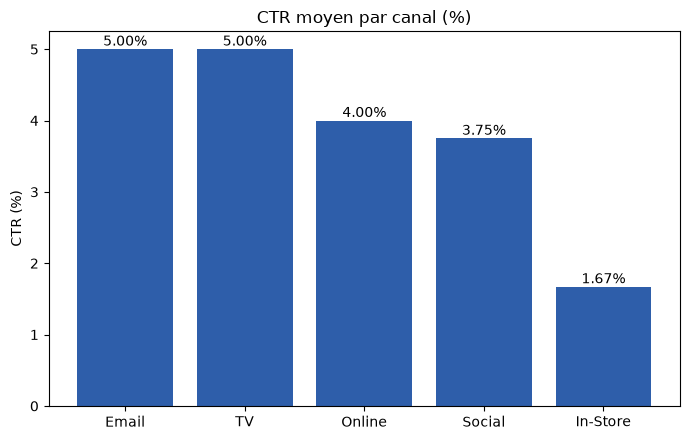

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = channel_summary.sort_values('avg_CTR', ascending=False)
ax.bar(order.index, order['avg_CTR'], color='#2E5EAA')
ax.set_title('CTR moyen par canal (%)')
ax.set_ylabel('CTR (%)')
for i, v in enumerate(order['avg_CTR']):
    ax.text(i, v + 0.05, f"{v:.2f}%", ha='center')
plt.tight_layout()
plt.savefig('../reports/figures/ctr_by_channel.png', dpi=150)
plt.show()


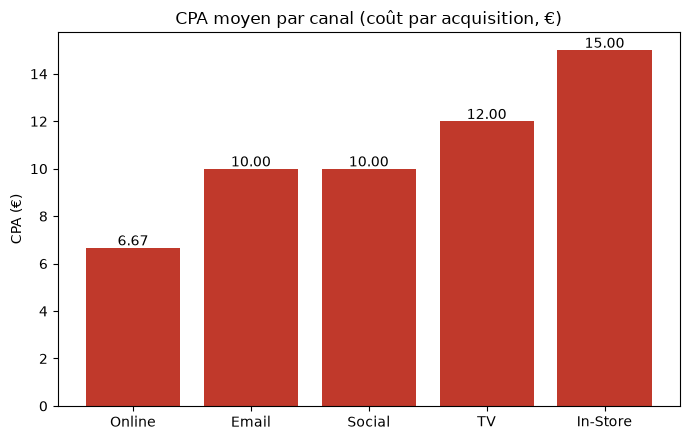

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = channel_summary.sort_values('avg_CPA', ascending=True)
ax.bar(order.index, order['avg_CPA'], color='#C0392B')
ax.set_title('CPA moyen par canal (coût par acquisition, €)')
ax.set_ylabel('CPA (€)')
for i, v in enumerate(order['avg_CPA']):
    ax.text(i, v + 0.1, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.savefig('../reports/figures/cpa_by_channel.png', dpi=150)
plt.show()


## 5. ROI par campagne (trié, code couleur positif/négatif)

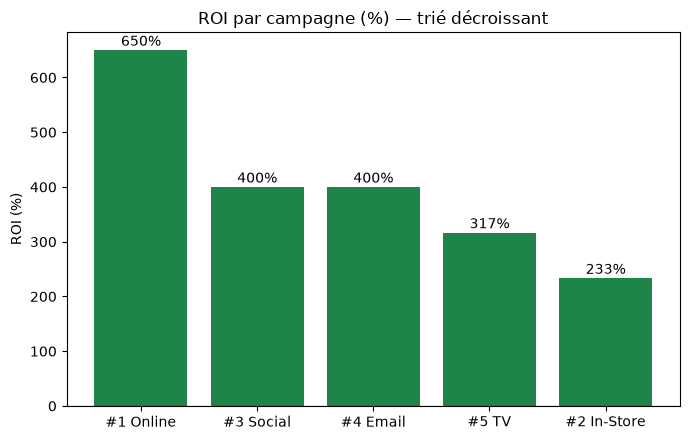

In [18]:
order = df.sort_values('ROI', ascending=False)
colors = ['#1E8449' if r >= 0 else '#C0392B' for r in order['ROI']]
labels = [f"#{cid} {ch}" for cid, ch in zip(order['Campaign_ID'], order['Channel'])]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(labels, order['ROI'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('ROI par campagne (%) — trié décroissant')
ax.set_ylabel('ROI (%)')
for i, v in enumerate(order['ROI']):
    ax.text(i, v + 8, f"{v:.0f}%", ha='center')
plt.tight_layout()
plt.savefig('../reports/figures/roi_by_campaign.png', dpi=150)
plt.show()


## 6. Relation Budget ↔ Conversions

Le budget engagé permet-il, proportionnellement, de générer plus de conversions ?


Corrélation Budget – Conversions : r = 0.904


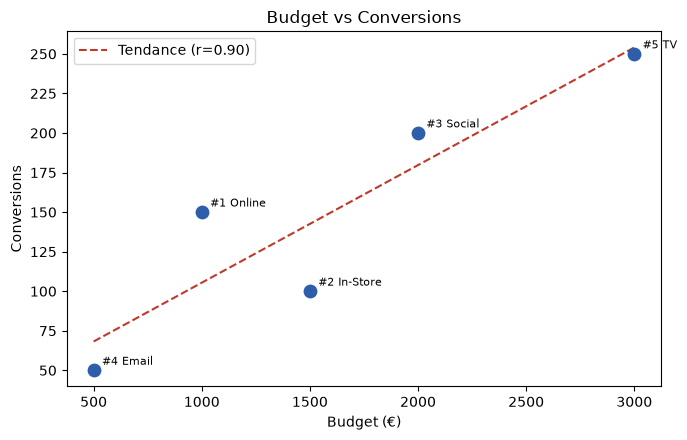

In [19]:
corr = df['Budget'].corr(df['Conversions'])
print(f"Corrélation Budget – Conversions : r = {corr:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df['Budget'], df['Conversions'], color='#2E5EAA', s=80, zorder=3)
for _, row in df.iterrows():
    ax.annotate(f"#{row['Campaign_ID']} {row['Channel']}",
                (row['Budget'], row['Conversions']),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

z = np.polyfit(df['Budget'], df['Conversions'], 1)
p = np.poly1d(z)
xs = np.linspace(df['Budget'].min(), df['Budget'].max(), 50)
ax.plot(xs, p(xs), color='#C0392B', linestyle='--', label=f'Tendance (r={corr:.2f})')

ax.set_xlabel('Budget (€)')
ax.set_ylabel('Conversions')
ax.set_title('Budget vs Conversions')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/budget_vs_conversions.png', dpi=150)
plt.show()


**Interprétation :** la corrélation est forte (r ≈ 0.90), mais l'échantillon est très
petit (5 campagnes), donc à interpréter avec prudence. Plus révélateur : le **CPA varie
de 6.67 € à 15.00 €** selon le canal (facteur ×2.25) — un budget plus élevé n'apporte
donc **pas** proportionnellement plus d'efficacité : TV, la campagne au budget le plus
élevé (3000 €), n'a que la 3ᵉ meilleure ROI (317 %), loin derrière Online (650 % pour
seulement 1000 € de budget).


## 7. Recommandations (4 à 6, chiffrées)

*Written in English as requested in the Person 4 specification.*

1. **Reallocate budget from In-Store to Online.** In-Store has the worst ROI (233%) and
   highest CPA (15.00€), while Online has the best ROI (650%) and lowest CPA (6.67€).
   Shifting €500 (33% of In-Store's €1,500 budget) to Online could generate roughly
   **75 conversions** (500€ / 6.67€ CPA) versus only ~33 conversions the same €500 would
   have produced at In-Store's CPA — a potential net gain of **+42 conversions**.

2. **Investigate In-Store's expensive clicks before scaling it further.** In-Store has
   the best Conversion_Rate of all channels (20.0%) but the worst CTR (1.67%) and highest
   CPC (3.00€), meaning traffic acquisition — not the offer — is the bottleneck. Recommend
   testing better targeting/creative to bring CPC below €2.00 before increasing its budget.

3. **Prioritize Online for incremental spend.** Online combines the lowest CPC (0.50€, tied
   with Email) with the best ROI (650%) and a strong CTR (4.00%). It is currently the
   smallest budget (€1,000, 14% of total spend) relative to its performance — a natural
   first candidate for additional investment.

4. **Trim TV's budget share modestly (~10%, ≈€300) and redistribute to Social/Online.** TV
   consumes the largest share of total spend (€3,000, 43% of the €8,000 total) but delivers
   only the 3rd-best ROI (317%). A partial (not full) reallocation preserves its high
   absolute conversion volume (250) while testing efficiency gains elsewhere.

5. **A/B test Email's landing page or offer.** Email ties for the best CTR (5.00%) and CPC
   (0.50€) — the ad itself performs well — but has the lowest Conversion_Rate (5.00%) of
   all channels. The drop-off happens after the click, suggesting the landing experience,
   not the targeting, needs optimization.

6. **Do not scale total marketing spend before fixing channel efficiency.** CPA varies by a
   factor of 2.25× across channels (€6.67 to €15.00) despite a high budget–conversions
   correlation (r=0.90 on this small 5-campaign sample). Equalizing efficiency toward
   Online/Social first will yield more conversions per euro than simply increasing overall
   budget.


## 8. Export du fichier de sortie (contrat du projet)

In [20]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)
print(f"Fichier exporté : {OUTPUT_PATH}")
df


Fichier exporté : ../data/processed/campaign_kpis.csv


,Campaign_ID,Channel,Start_Date,End_Date,Duration_days,Budget,Impressions,Clicks,Conversions,CTR,Conversion_Rate,CPC,CPA,Estimated_Revenue,ROI
0,1,Online,2023-01-01,2023-01-15,14,1000.0,50000,2000,150,4.00,7.50,0.50,6.67,7500.0,650.00
1,2,In-Store,2023-01-10,2023-01-20,10,1500.0,30000,500,100,1.67,20.00,3.00,15.00,5000.0,233.33
2,3,Social,2023-01-15,2023-01-25,10,2000.0,40000,1500,200,3.75,13.33,1.33,10.00,10000.0,400.00
3,4,Email,2023-01-05,2023-01-15,10,500.0,20000,1000,50,5.00,5.00,0.50,10.00,2500.0,400.00
4,5,TV,2023-01-01,2023-01-31,30,3000.0,60000,3000,250,5.00,8.33,1.00,12.00,12500.0,316.67
